In [1]:
# =============================================================================
# 15 — Alpha ablation, appendix
#
# The main analysis used three alignment weights, 0, 3 and 5. This notebook
# fills in the curve.
#
# TWO AXES, and only one of them touches the clinician data.
#   class correlation   computed from the model alone, no annotations
#   alignment AUC       requires the annotations
#
# Selecting an operating point on discriminativeness is therefore clean.
# Selecting on alignment AUC and then reporting that same AUC would be
# circular, so the Pareto is presented descriptively.
#
# THE QUESTION. Is there an alpha that grounds the explanation while
# preserving class specificity, or are the two in direct tension.
# =============================================================================
from pathlib import Path
import sys, re
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score


def find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "scripts" / "generate_finer_cam_panderm.py").exists():
            return p.resolve()
    raise FileNotFoundError


REPO = find_repo_root()
for extra in [REPO, REPO / "external" / "PanDerm" / "classification"]:
    if str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

from src.eval.cam_eval_utils import (
    mask_to_cam_grid_geom, norm01, CAM_GRID, CROP_SIZE)

GEOMETRY = "squash224"
POOLING  = "mean"
POOL_TAG = "gap" if POOLING == "mean" else "cls"
BLOCK    = -1
TOP_K    = 20
MEL_IDX, NV_IDX = 0, 1
CLASSES  = ["MEL", "NV"]

HAM_ROOT   = REPO / "data" / "HAM10000"
ALPHA_DIR  = REPO / "external" / "checkpoints_alpha"
MAIN_DIR   = REPO / "external" / "checkpoints5"
EVAL_ROOT  = REPO / "outputs" / "mel_nv" / "eval_cams" / POOL_TAG / GEOMETRY
QC_CSV     = REPO / "results" / "annotation_qc" / GEOMETRY / "annotation_qc_manifest.csv"
OUT        = REPO / "results" / "alpha_ablation" / POOL_TAG
OUT.mkdir(parents=True, exist_ok=True)

DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")

C_ATTN, C_MEL = "#1F77B4", "#C62828"
mpl.rcParams.update({"figure.dpi": 130, "savefig.dpi": 300,
                     "savefig.bbox": "tight", "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

eval_df = pd.read_csv(EVAL_ROOT / "eval_images.csv")
qcp     = pd.read_csv(QC_CSV).query("qc_pass")

print(f"geometry {GEOMETRY}   pooling {POOL_TAG}   device {DEVICE}")
print(f"images {len(eval_df)}")

geometry squash224   pooling gap   device mps
images 34


In [2]:
# =============================================================================
# Collect every alpha checkpoint. Handles both the clean convention and the
# raw sweep filenames.
# =============================================================================
def parse_alpha(name):
    m = re.search(r"[-_]ha([\d]+(?:[p.]\d+)?)", name)
    if not m or "dal" in name.lower():
        return None
    return float(m.group(1).replace("p", "."))


def parse_pool(name):
    m = re.search(r"[-_](gap|cls)[-_]", name)
    return m.group(1) if m else None


ckpts = {}
for d in [MAIN_DIR, ALPHA_DIR]:
    if not d.exists():
        print(f"  not found: {d}")
        continue
    for f in sorted(d.glob("*.pth")):
        a = parse_alpha(f.name)
        p = parse_pool(f.name)
        if a is None or p != POOL_TAG:
            continue
        if a not in ckpts:
            ckpts[a] = f

ALPHAS = sorted(ckpts)
print(f"{len(ALPHAS)} alpha values for {POOL_TAG}")
for a in ALPHAS:
    print(f"  alpha {a:>6g}   {ckpts[a].name}")

if len(ALPHAS) < 4:
    print("\nFewer than four values. The Pareto will be sparse.")
    print(f"Expected the ablation checkpoints in {ALPHA_DIR}")

10 alpha values for gap
  alpha      0   checkpoint-best-gap-ha0.pth
  alpha    0.1   checkpoint-best-gap-ha0p1.pth
  alpha   0.25   checkpoint-best-gap-ha0p25.pth
  alpha    0.5   checkpoint-best-gap-ha0p5.pth
  alpha      1   checkpoint-best-gap-ha1.pth
  alpha      3   checkpoint-best-gap-ha3.pth
  alpha      5   checkpoint-best-gap-ha5.pth
  alpha      7   checkpoint-best-gap-ha7.pth
  alpha     11   checkpoint-best-gap-ha11.pth
  alpha     17   checkpoint-best-gap-ha17.pth


In [3]:
# =============================================================================
# Identical machinery to 12e. Duplicated so this notebook stands alone.
# =============================================================================
from run_class_finetuning_ha import (
    build_attention_gradcam_map, _unwrap_model, unpack_model_outputs)
from scripts.generate_finer_cam_panderm import (
    build_panderm_model, remap_official_finetune_checkpoint_keys,
    extract_checkpoint_state_dict, infer_panderm_variant_from_state_dict,
    infer_checkpoint_pooling)

PREPROCESS = T.Compose([
    T.Resize((CROP_SIZE, CROP_SIZE), interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

_cache = {}


def load_model(alpha):
    if alpha in _cache:
        return _cache[alpha]
    p = ckpts[alpha]
    ck = torch.load(p, map_location="cpu", weights_only=False)
    raw, _ = extract_checkpoint_state_dict(ck)

    got = infer_checkpoint_pooling(ck, raw)
    if got is not None and got != POOLING:
        raise RuntimeError(f"alpha {alpha}: pooling {got}, expected {POOLING}")

    st = remap_official_finetune_checkpoint_keys(raw)
    m = build_panderm_model(num_classes=2,
                            variant=infer_panderm_variant_from_state_dict(st),
                            use_mean_pooling=(POOLING == "mean"))
    miss, unexp = m.load_state_dict(st, strict=False)
    bad = [k for k in list(miss) + list(unexp)
           if k.startswith(("norm.", "fc_norm.", "head."))]
    if bad:
        raise RuntimeError(f"alpha {alpha}: critical keys {bad}")

    m.to(DEVICE).eval()
    for q in m.parameters():
        q.requires_grad_(True)
    _cache[alpha] = m
    return m


def load_tensor(rel):
    img = Image.open((HAM_ROOT / str(rel)).resolve()).convert("RGB")
    return PREPROCESS(img).unsqueeze(0).to(DEVICE)


def class_maps(model, x):
    base = _unwrap_model(model)
    base.clear_xai_state()
    with torch.enable_grad():
        out = model(x, return_patch_tokens=True, store_attn=True,
                    attn_layer=BLOCK)
        logits, _ = unpack_model_outputs(out)
        cams = []
        for idx in (MEL_IDX, NV_IDX):
            t = torch.full((1,), idx, device=logits.device, dtype=torch.long)
            cams.append(build_attention_gradcam_map(
                model, logits, t, create_graph=False).detach())
        probs = torch.softmax(logits.detach(), 1)[0].float().cpu().numpy()
    base.clear_xai_state()
    return (cams[0][0].float().cpu().numpy(),
            cams[1][0].float().cpu().numpy(), probs)


def topk_fixed(c, k=TOP_K):
    f = np.asarray(c, np.float32).ravel()
    o = np.zeros(f.size, bool)
    o[np.argpartition(-f, k - 1)[:k]] = True
    return o.reshape(c.shape)


def mel_union_grid(image_id):
    sub = qcp[(qcp.Image_ID == image_id) & (qcp.label_group == "MEL")]
    if not len(sub):
        return None
    acc = None
    for _, r in sub.iterrows():
        m = np.array(Image.open(r.mask_path).convert("L")) > 127
        acc = m if acc is None else (acc | m)
    return mask_to_cam_grid_geom(acc, GEOMETRY) >= 0.5


UNIONS = {i: mel_union_grid(i) for i in eval_df.image_id}
print("ready")

ready


In [4]:
# =============================================================================
# About one minute per alpha on MPS.
# =============================================================================
rows = []
for a in ALPHAS:
    model = load_model(a)
    for _, r in eval_df.iterrows():
        x = load_tensor(r.image_rel_path)
        cm, cn, probs = class_maps(model, x)

        va, vb = norm01(cm).ravel(), norm01(cn).ravel()
        ma, mb = topk_fixed(norm01(cm)), topk_fixed(norm01(cn))
        tgt = cm if r.gt_label == "MEL" else cn
        un = UNIONS.get(r.image_id)

        rows.append({
            "alpha": a, "image_id": r.image_id, "gt_label": r.gt_label,
            "class_pearson": float(np.corrcoef(va, vb)[0, 1]),
            "class_topk_iou": float((ma & mb).sum() / ((ma | mb).sum() + 1e-8)),
            "mel_auc": (float(roc_auc_score(un.ravel(), norm01(tgt).ravel()))
                        if un is not None and 0 < un.sum() < un.size else np.nan),
            "pointing": (float(un[np.unravel_index(np.argmax(norm01(tgt)),
                                                   tgt.shape)])
                         if un is not None else np.nan),
            "pred": CLASSES[int(np.argmax(probs))],
        })
    print(f"  done alpha {a:g}")

per = pd.DataFrame(rows)
per["correct"] = per.gt_label == per.pred
per["pooling"] = POOL_TAG
per.to_csv(OUT / "alpha_per_image.csv", index=False)
print(f"\n{len(per)} rows across {per.alpha.nunique()} alpha values")

  done alpha 0
  done alpha 0.1
  done alpha 0.25
  done alpha 0.5
  done alpha 1
  done alpha 3
  done alpha 5
  done alpha 7
  done alpha 11
  done alpha 17

340 rows across 10 alpha values


In [5]:
# =============================================================================
# READ  class_pearson near 0 is good, class specificity preserved.
#       mel_auc high is good, explanation grounded.
#       An operating point would have BOTH.
# =============================================================================
def boot_ci(x, n=4000, seed=0):
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    b = [np.median(rng.choice(x, len(x), replace=True)) for _ in range(n)]
    return float(np.median(x)), float(np.percentile(b, 2.5)), \
           float(np.percentile(b, 97.5))


rows = []
for a, g in per.groupby("alpha"):
    pm, plo, phi = boot_ci(g.class_pearson)
    am, alo, ahi = boot_ci(g.mel_auc)
    rows.append({
        "alpha": a, "n": g.image_id.nunique(),
        "class_pearson": pm, "pearson_ci": f"[{plo:+.3f}, {phi:+.3f}]",
        "class_topk_iou": g.class_topk_iou.median(),
        "mel_auc": am, "auc_ci": f"[{alo:.3f}, {ahi:.3f}]",
        "pointing": f"{int(g.pointing.sum())}/{int(g.pointing.notna().sum())}",
        "subset_acc": g.correct.mean(),
    })

s = pd.DataFrame(rows).sort_values("alpha")
s["pooling"] = POOL_TAG
s.to_csv(OUT / "alpha_summary.csv", index=False)

print("=" * 96)
print(f"ALPHA ABLATION, {POOL_TAG.upper()}, attention-CAM")
print("=" * 96)
print(s.round(4).to_string(index=False))

lo = s[s.alpha == s.alpha.min()].iloc[0]
hi = s[s.alpha == s.alpha.max()].iloc[0]
print(f"\nalpha {lo.alpha:g}  correlation {lo.class_pearson:+.3f}  "
      f"AUC {lo.mel_auc:.3f}")
print(f"alpha {hi.alpha:g}  correlation {hi.class_pearson:+.3f}  "
      f"AUC {hi.mel_auc:.3f}")

knee = s[(s.class_pearson < 0.5) & (s.mel_auc > 0.85)]
print(f"\nalpha values with correlation below 0.5 AND AUC above 0.85: "
      f"{len(knee)}")
if len(knee):
    print(knee[["alpha", "class_pearson", "mel_auc"]].round(3)
          .to_string(index=False))
    print("\nAn operating point exists. This is the value to report.")
else:
    print("\nNo operating point. Grounding and class specificity are in")
    print("direct tension across the entire range tested.")

cross = s[s.class_pearson > 0.5].alpha.min() if (s.class_pearson > 0.5).any() \
        else None
if cross is not None:
    print(f"\ncollapse first exceeds r = 0.5 at alpha = {cross:g}")

ALPHA ABLATION, GAP, attention-CAM
 alpha  n  class_pearson       pearson_ci  class_topk_iou  mel_auc         auc_ci pointing  subset_acc pooling
  0.00 34        -0.2407 [-0.261, -0.213]          0.0000   0.5758 [0.449, 0.635]     5/31      0.6471     gap
  0.10 34         0.8759 [+0.850, +0.891]          0.4286   0.9476 [0.918, 0.971]    28/31      0.6471     gap
  0.25 34         0.9319 [+0.923, +0.942]          0.4815   0.9472 [0.933, 0.973]    28/31      0.6471     gap
  0.50 34         0.9508 [+0.946, +0.962]          0.4815   0.9609 [0.941, 0.971]    25/31      0.6471     gap
  1.00 34         0.9627 [+0.953, +0.970]          0.5100   0.9631 [0.948, 0.971]    25/31      0.6471     gap
  3.00 34         0.9688 [+0.960, +0.976]          0.5385   0.9637 [0.952, 0.976]    24/31      0.5882     gap
  5.00 34         0.9704 [+0.961, +0.975]          0.4550   0.9654 [0.955, 0.977]    21/31      0.5882     gap
  7.00 34         0.9781 [+0.962, +0.986]          0.5692   0.9615 [0.956, 0.

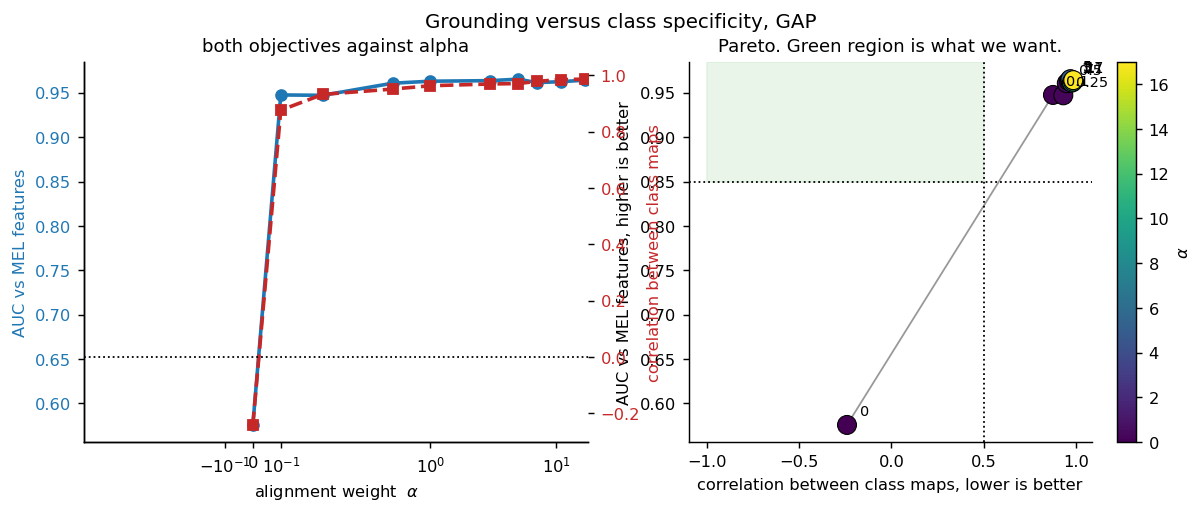

In [6]:
# =============================================================================
# FIGURE. The tradeoff.
#
# READ  left   both quantities against alpha. Where do they cross.
#       right  the Pareto. The upper LEFT corner is what we want, grounded
#              AND class specific. A point there is an operating point.
#              A straight line from lower left to upper right means the two
#              are in direct tension.
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

a2 = ax[0].twinx()
ax[0].plot(s.alpha, s.mel_auc, "o-", color=C_ATTN, lw=2, ms=6,
           label="alignment AUC")
a2.plot(s.alpha, s.class_pearson, "s--", color=C_MEL, lw=2, ms=6,
        label="class correlation")
ax[0].set_xlabel(r"alignment weight  $\alpha$")
ax[0].set_ylabel("AUC vs MEL features", color=C_ATTN)
a2.set_ylabel("correlation between class maps", color=C_MEL)
a2.axhline(0, color="k", ls=":", lw=1)
ax[0].tick_params(axis="y", labelcolor=C_ATTN)
a2.tick_params(axis="y", labelcolor=C_MEL)
if s.alpha.max() / max(s.alpha[s.alpha > 0].min(), 0.01) > 20:
    ax[0].set_xscale("symlog", linthresh=0.5)
ax[0].set_title("both objectives against alpha", fontsize=10)

sc = ax[1].scatter(s.class_pearson, s.mel_auc, c=s.alpha, cmap="viridis",
                   s=110, edgecolor="black", linewidth=0.6, zorder=3)
for _, r in s.iterrows():
    ax[1].annotate(f"{r.alpha:g}", (r.class_pearson, r.mel_auc),
                   textcoords="offset points", xytext=(7, 5), fontsize=8)
ax[1].plot(s.sort_values("alpha").class_pearson,
           s.sort_values("alpha").mel_auc, "-", color="#999", lw=1, zorder=1)
ax[1].axhline(0.85, color="k", ls=":", lw=1)
ax[1].axvline(0.5, color="k", ls=":", lw=1)
ax[1].axvspan(-1, 0.5, ymin=(0.85 - ax[1].get_ylim()[0]) /
              (ax[1].get_ylim()[1] - ax[1].get_ylim()[0]),
              color="#C8E6C9", alpha=0.4, zorder=0)
ax[1].set_xlabel("correlation between class maps, lower is better")
ax[1].set_ylabel("AUC vs MEL features, higher is better")
ax[1].set_title("Pareto. Green region is what we want.", fontsize=10)
plt.colorbar(sc, ax=ax[1], label=r"$\alpha$")

fig.suptitle(f"Grounding versus class specificity, {POOL_TAG.upper()}",
             fontsize=11)
fig.savefig(OUT / "fig_alpha_pareto.png")
plt.show()

In [7]:
# =============================================================================
# Draft text for the appendix.
# =============================================================================
lo = s.iloc[0]
hi = s.iloc[-1]
knee = s[(s.class_pearson < 0.5) & (s.mel_auc > 0.85)]

print(f"""
ALPHA ABLATION, DRAFT TEXT

The alignment weight was swept across {len(s)} values from {s.alpha.min():g}
to {s.alpha.max():g}, each trained independently from the foundation
checkpoint. Two quantities were measured on the {lo.n} annotated images:
agreement between the explanation and the clinician feature annotations,
and correlation between the melanoma and nevus attention maps.

Only the first requires the annotations, so selecting an operating point on
class specificity does not use the evaluation data.""")

if len(knee):
    b = knee.sort_values("mel_auc", ascending=False).iloc[0]
    print(f"""
An operating point exists. At alpha = {b.alpha:g} the explanation reaches
AUC {b.mel_auc:.3f} against the clinician features while the class maps
remain distinguishable at r = {b.class_pearson:+.3f}. Grounding and class
specificity are therefore not strictly incompatible, though the window is
narrow.""")
else:
    print(f"""
No operating point was found. Every weight that grounds the explanation
also collapses class specificity. Agreement rises from {lo.mel_auc:.3f} at
alpha = {lo.alpha:g} to {hi.mel_auc:.3f} at alpha = {hi.alpha:g}, while the
class map correlation rises from {lo.class_pearson:+.3f} to
{hi.class_pearson:+.3f} over the same range. In this architecture the two
objectives are in direct tension.""")

print(f"""
The chosen operating point for the main analysis, alpha = 5, was fixed
before this ablation. Alignment saturates by alpha = 3 on every metric,
so the choice is not critical for grounding, but it lies well inside the
collapsed region for class specificity.

Sweep in {OUT.relative_to(REPO)}
""")


ALPHA ABLATION, DRAFT TEXT

The alignment weight was swept across 10 values from 0
to 17, each trained independently from the foundation
checkpoint. Two quantities were measured on the 34 annotated images:
agreement between the explanation and the clinician feature annotations,
and correlation between the melanoma and nevus attention maps.

Only the first requires the annotations, so selecting an operating point on
class specificity does not use the evaluation data.

No operating point was found. Every weight that grounds the explanation
also collapses class specificity. Agreement rises from 0.576 at
alpha = 0 to 0.964 at alpha = 17, while the
class map correlation rises from -0.241 to
+0.986 over the same range. In this architecture the two
objectives are in direct tension.

The chosen operating point for the main analysis, alpha = 5, was fixed
before this ablation. Alignment saturates by alpha = 3 on every metric,
so the choice is not critical for grounding, but it lies well inside 